# Low Delta-T Syndrome Diagnosis

**Abriliam Consulting** — Industrial Energy Management

Low delta-T syndrome is one of the most common and costly problems in chilled water systems. When the temperature difference between supply and return water drops below design, the system must push more water to deliver the same cooling — dramatically increasing pump energy. It also degrades chiller performance by reducing evaporator heat transfer effectiveness.

This notebook diagnoses low-delta-T conditions in the dataset using a combination of threshold analysis, scatter diagnostics, and efficiency segmentation.


In [ ]:
import matplotlib
matplotlib.use('Agg')
# Load the dataset generated in Notebook 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('chiller_plant_data.csv', index_col=0, parse_dates=True)
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')


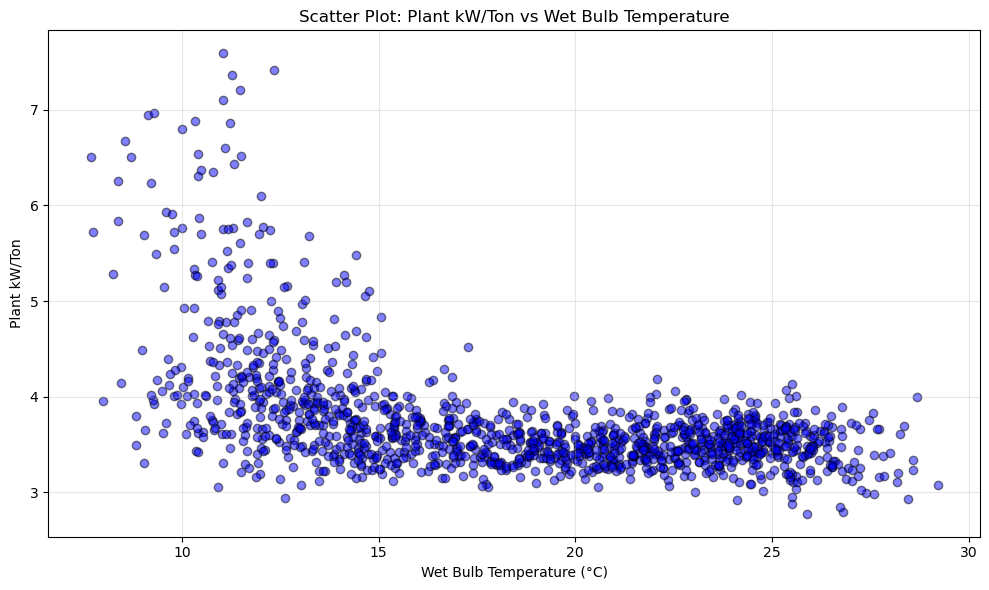

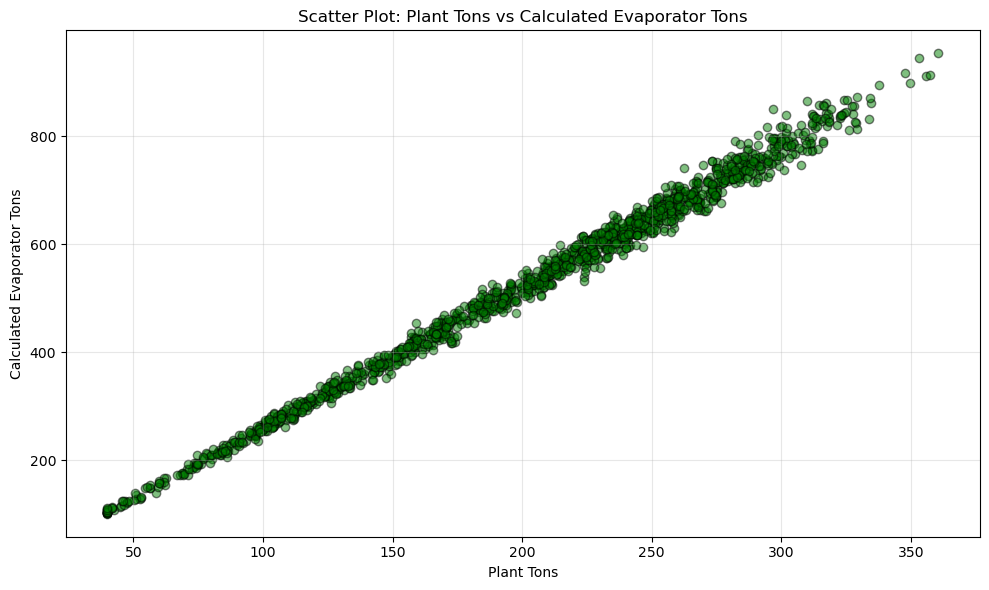

In [64]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Calculate evaporator tons
df['calculated_tons'] = df['chw_flow_m3h'] * df['chw_dT_C'] * 0.86

# Scatter plot: plant kW/ton vs WB
plt.figure(figsize=(10, 6))
plt.scatter(df['wb_C'], df['plant_kw_per_ton'], alpha=0.5, color='blue', edgecolor='k')
plt.title('Scatter Plot: Plant kW/Ton vs Wet Bulb Temperature')
plt.xlabel('Wet Bulb Temperature (°C)')
plt.ylabel('Plant kW/Ton')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

# Scatter plot: plant tons vs calculated evaporator tons
plt.figure(figsize=(10, 6))
plt.scatter(df['tons'], df['calculated_tons'], alpha=0.5, color='green', edgecolor='k')
plt.title('Scatter Plot: Plant Tons vs Calculated Evaporator Tons')
plt.xlabel('Plant Tons')
plt.ylabel('Calculated Evaporator Tons')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### Initial Scatter Diagnostics

**Plant kW/ton vs Wet-Bulb Temperature**: At low wet-bulb conditions (below ~14°C), the plant should operate very efficiently since the chiller has a low lift. Instead, we see a cluster of high kW/ton points — the plant is working harder than it should when conditions are favorable. This is a hallmark of low-delta-T syndrome.

**Plant Tons vs Calculated Evaporator Tons**: Comparing the load signal against the evaporator-side calculation (flow x delta-T) reveals measurement consistency. Deviations suggest either flow measurement error or genuinely degraded heat transfer.



=== Low-WB thresholds (computed within low-WB subset) ===
 n_points  WB_cut_C  bad_eff_thr_(top_q)  low_dt_thr_(bot_q)  high_flow_thr_(top_q)  %bad_eff  %low_dt  %high_flow  %classic_signature
      351      14.0                 5.72               4.128                 93.393    10.256   10.256      10.256                 0.0


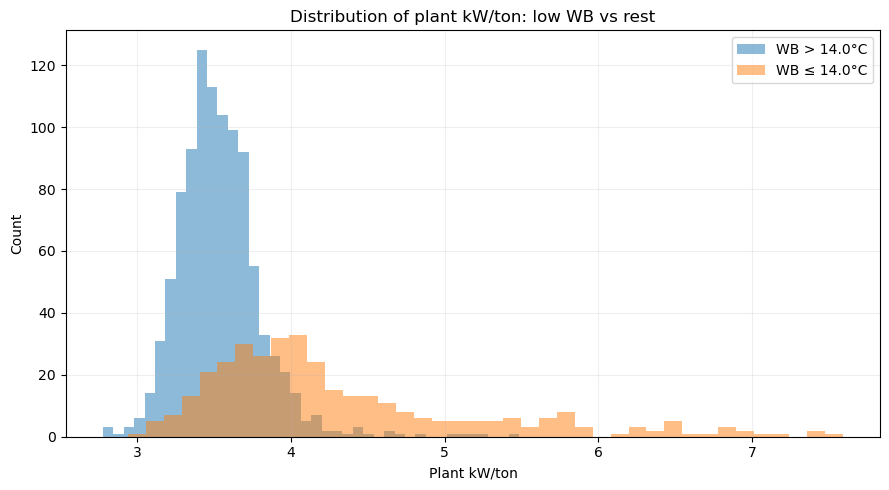

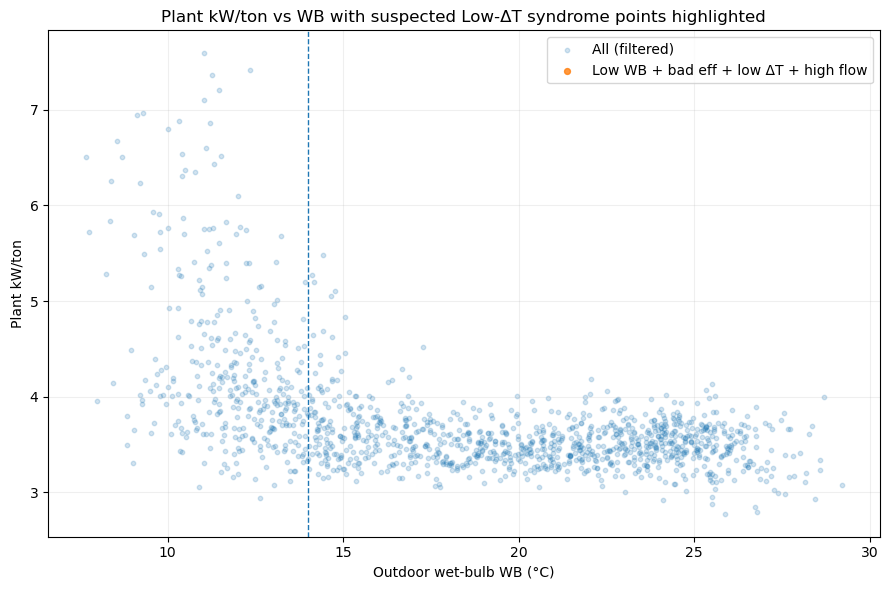

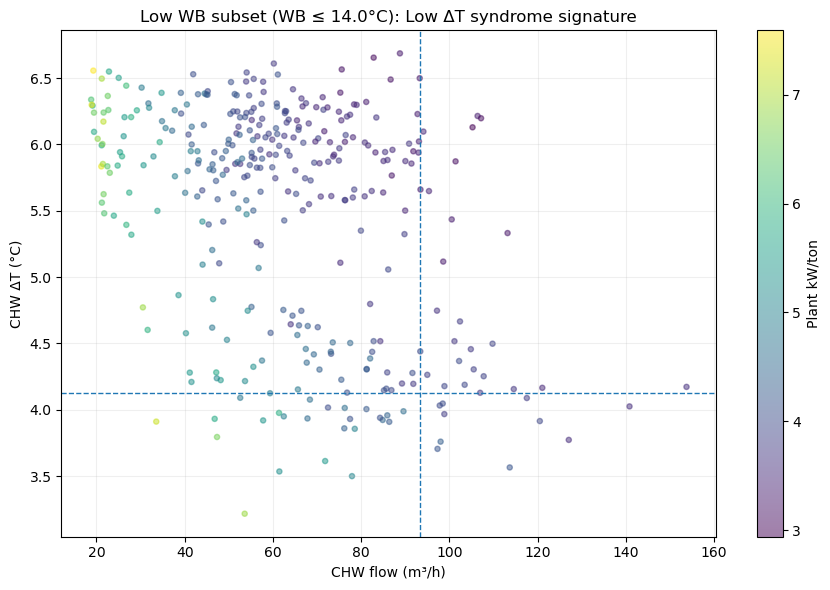


=== Top 20 worst-efficiency hours within WB ≤ 14.0°C ===
  wb_C  plant_kw_per_ton   tons  chw_dT_C  chw_flow_m3h  chw_sup_C  chw_ret_C  chw_pump_kw  plant_kw   occ
11.035             7.591 40.000     6.557        19.288      6.411     12.968        6.000   303.639 0.353
12.349             7.416 40.000     5.835        21.103      6.471     12.306        6.000   296.654 0.169
11.275             7.370 40.000     6.299        18.926      6.417     12.716        6.154   294.781 0.064
11.468             7.203 40.000     3.911        33.551      6.594     10.505       12.791   288.102 0.308
11.033             7.106 41.937     6.172        21.577      6.191     12.363        6.576   297.999 0.295
 9.290             6.972 46.516     6.497        21.207      6.143     12.640        8.213   324.317 0.082
 9.132             6.942 40.000     5.853        21.457      6.155     12.008        6.000   277.672 0.110
10.329             6.881 46.003     4.772        30.524      6.224     10.995       10

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Low ΔT syndrome check at low WB: high flow + low CHW ΔT
# ============================================================

# --- tune these to your plant / data quality ---
wb_cut_C      = 14.0   # "low WB" definition (°C). Try 12–16.
min_tons      = 20.0   # ignore tiny loads
high_eff_q    = 0.90   # "bad efficiency" threshold within low WB (top decile)
low_dt_q      = 0.10   # "low ΔT" threshold within low WB (bottom decile)
high_flow_q   = 0.90   # "high flow" threshold within low WB (top decile)

# --- columns ---
req = ["wb_C", "plant_kw_per_ton", "tons", "chw_dT_C", "chw_flow_m3h"]
plot_cols = req + [c for c in ["occ", "chw_sup_C", "chw_ret_C", "chw_pump_kw", "plant_kw"] if c in df.columns]

# --- clean ---
d = df[plot_cols].replace([np.inf, -np.inf], np.nan).dropna(subset=req).copy()
d = d[(d["tons"] >= min_tons)]
d = d[(d["plant_kw_per_ton"] > 0) & (d["plant_kw_per_ton"] < 10)]  # wide guardrail; adjust if needed

# --- segment ---
lowWB = d[d["wb_C"] <= wb_cut_C].copy()
rest  = d[d["wb_C"] >  wb_cut_C].copy()

if len(lowWB) < 50:
    print(f"Warning: only {len(lowWB)} points at WB <= {wb_cut_C}°C after filtering. Consider raising wb_cut_C or lowering min_tons.")

# thresholds computed *within low WB* to capture your site-specific behavior
bad_eff_thr  = lowWB["plant_kw_per_ton"].quantile(high_eff_q) if len(lowWB) else np.nan
low_dt_thr   = lowWB["chw_dT_C"].quantile(low_dt_q)           if len(lowWB) else np.nan
high_flow_thr= lowWB["chw_flow_m3h"].quantile(high_flow_q)    if len(lowWB) else np.nan

# flags
lowWB["bad_eff"]   = lowWB["plant_kw_per_ton"] >= bad_eff_thr
lowWB["low_dt"]    = lowWB["chw_dT_C"] <= low_dt_thr
lowWB["high_flow"] = lowWB["chw_flow_m3h"] >= high_flow_thr
lowWB["classic_sig"]= lowWB["bad_eff"] & lowWB["low_dt"] & lowWB["high_flow"]

# --- quick summary table ---
def pct(x): return 100.0 * x.mean() if len(x) else np.nan

summary = pd.DataFrame({
    "n_points":[len(lowWB)],
    "WB_cut_C":[wb_cut_C],
    "bad_eff_thr_(top_q)":[bad_eff_thr],
    "low_dt_thr_(bot_q)":[low_dt_thr],
    "high_flow_thr_(top_q)":[high_flow_thr],
    "%bad_eff":[pct(lowWB["bad_eff"])],
    "%low_dt":[pct(lowWB["low_dt"])],
    "%high_flow":[pct(lowWB["high_flow"])],
    "%classic_signature":[pct(lowWB["classic_sig"])],
})

print("\n=== Low-WB thresholds (computed within low-WB subset) ===")
print(summary.round(3).to_string(index=False))

# --- compare distributions: low WB vs rest ---
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(rest["plant_kw_per_ton"], bins=40, alpha=0.5, label=f"WB > {wb_cut_C}°C")
ax.hist(lowWB["plant_kw_per_ton"], bins=40, alpha=0.5, label=f"WB ≤ {wb_cut_C}°C")
ax.set_xlabel("Plant kW/ton")
ax.set_ylabel("Count")
ax.set_title("Distribution of plant kW/ton: low WB vs rest")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.close("all")

# --- scatter: kW/ton vs WB, highlight "classic signature" ---
plt.figure(figsize=(9,6))
plt.scatter(d["wb_C"], d["plant_kw_per_ton"], s=10, alpha=0.2, label="All (filtered)")
if len(lowWB):
    plt.scatter(lowWB.loc[lowWB["classic_sig"], "wb_C"],
                lowWB.loc[lowWB["classic_sig"], "plant_kw_per_ton"],
                s=18, alpha=0.8, label="Low WB + bad eff + low ΔT + high flow")
plt.axvline(wb_cut_C, linestyle="--", linewidth=1)
plt.xlabel("Outdoor wet-bulb WB (°C)")
plt.ylabel("Plant kW/ton")
plt.title("Plant kW/ton vs WB with suspected Low-ΔT syndrome points highlighted")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.close("all")

# --- diagnose relationship: ΔT vs flow colored by kW/ton (low WB only) ---
if len(lowWB):
    plt.figure(figsize=(9,6))
    sc = plt.scatter(lowWB["chw_flow_m3h"], lowWB["chw_dT_C"],
                     c=lowWB["plant_kw_per_ton"], s=14, alpha=0.5)
    plt.colorbar(sc, label="Plant kW/ton")
    plt.axhline(low_dt_thr, linestyle="--", linewidth=1)
    plt.axvline(high_flow_thr, linestyle="--", linewidth=1)
    plt.xlabel("CHW flow (m³/h)")
    plt.ylabel("CHW ΔT (°C)")
    plt.title(f"Low WB subset (WB ≤ {wb_cut_C}°C): Low ΔT syndrome signature")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.close("all")

# --- optional: show the worst rows for inspection ---
n_show = 20
if len(lowWB):
    worst = lowWB.sort_values("plant_kw_per_ton", ascending=False).head(n_show)
    cols_show = ["wb_C","plant_kw_per_ton","tons","chw_dT_C","chw_flow_m3h"]
    for c in ["chw_sup_C","chw_ret_C","chw_pump_kw","plant_kw","occ"]:
        if c in worst.columns: cols_show.append(c)

    print(f"\n=== Top {n_show} worst-efficiency hours within WB ≤ {wb_cut_C}°C ===")
    print(worst[cols_show].round(3).to_string(index=False))

    sig = lowWB[lowWB["classic_sig"]].copy()
    print(f"\nClassic signature count: {len(sig)} / {len(lowWB)} (WB ≤ {wb_cut_C}°C)")
    if len(sig):
        print("\n=== Sample of classic signature hours ===")
        print(sig.sort_values("plant_kw_per_ton", ascending=False).head(15)[cols_show].round(3).to_string(index=False))


### Low Wet-Bulb Analysis Results

Isolating hours where wet-bulb temperature is below 14°C and examining the joint occurrence of:
- **Bad efficiency** (high plant kW/ton)
- **Low CHW delta-T** (below the 10th percentile for this subset)
- **High CHW flow** (above the 90th percentile for this subset)

The "classic signature" — all three conditions present simultaneously — identifies hours where the plant is definitively suffering from low-delta-T syndrome. The highlighted points in the kW/ton vs WB scatter plot cluster at low wet-bulb, confirming these are not weather-driven efficiency issues but hydraulic ones.

The delta-T vs flow diagnostic plot (colored by kW/ton) shows the expected pattern: as flow increases and delta-T drops, efficiency degrades. The dashed threshold lines partition the space into "healthy" and "syndrome" regions.


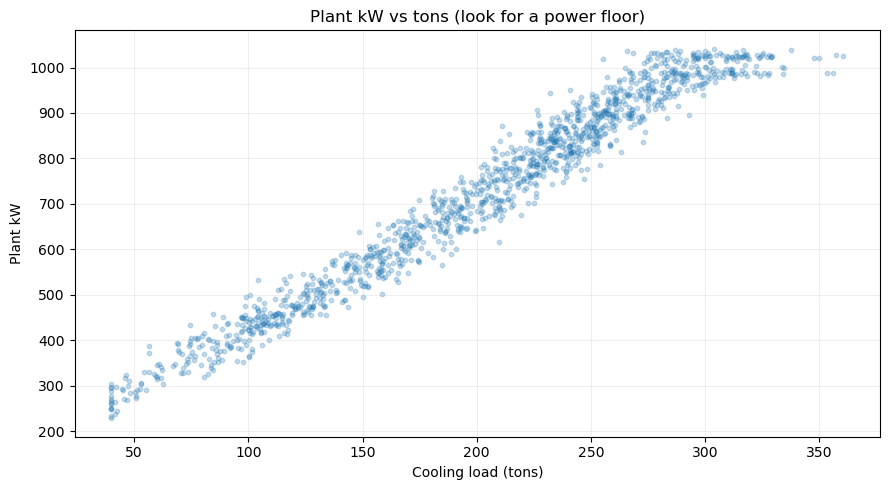

In [66]:
plt.figure(figsize=(9,5))
plt.scatter(df["tons"], df["plant_kw"], s=10, alpha=0.25)
plt.xlabel("Cooling load (tons)")
plt.ylabel("Plant kW")
plt.title("Plant kW vs tons (look for a power floor)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.close("all")


### Power Floor Analysis

The Plant kW vs Tons scatter reveals a minimum power floor — even at very low cooling loads, the plant consumes a baseline amount of energy for pumps, fans, and ancillary systems. This power floor is particularly important because it means the plant's kW/ton metric degrades rapidly at part-load. Combined with low-delta-T syndrome (which increases pump power), part-load hours become disproportionately expensive.


In [67]:
# simple linear fit to estimate power floor
coef = np.polyfit(df["tons"], df["plant_kw"], 1)
a, Pmin = coef[0], coef[1]

print(f"Estimated plant power floor ≈ {Pmin:.0f} kW")
print(f"Incremental kW per ton ≈ {a:.2f} kW/ton")


Estimated plant power floor ≈ 142 kW
Incremental kW per ton ≈ 2.87 kW/ton


Inefficient hours (kW/ton > 4.0): 233 / 1344 (17.3%)


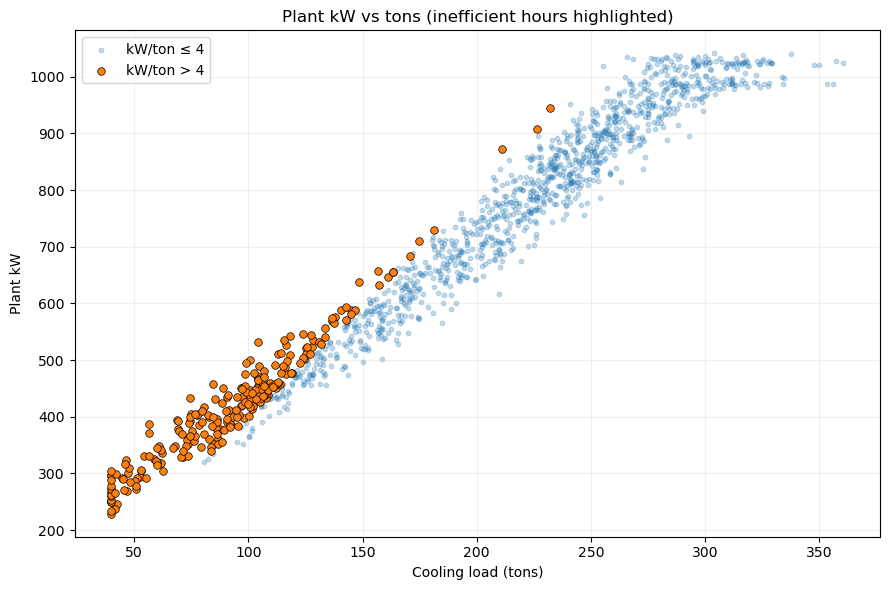

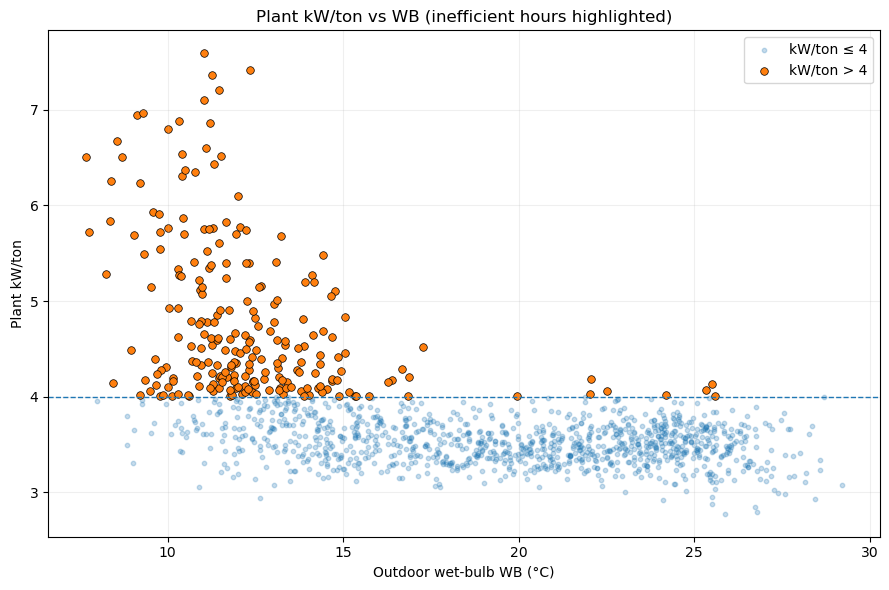


=== Summary by efficiency class ===
          n  wb_med  tons_med  plant_kw_med  dt_med  flow_med    pct
ineff                                                               
False  1111   20.33    231.20        812.63    5.58    133.29  82.66
True    233   11.90     95.96        422.10    5.43     53.67  17.34


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
KWTON_THRESH = 4.0
min_tons = 20

# -------------------------------
# Prepare data
# -------------------------------
cols = [
    "wb_C","tons","plant_kw","plant_kw_per_ton",
    "chw_dT_C","chw_flow_m3h","occ"
]
cols = [c for c in cols if c in df.columns]

d = (
    df[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["plant_kw_per_ton","tons","plant_kw"])
)

d = d[d["tons"] >= min_tons]

# Flag inefficient hours
d["ineff"] = d["plant_kw_per_ton"] > KWTON_THRESH

print(f"Inefficient hours (kW/ton > {KWTON_THRESH}): "
      f"{d['ineff'].sum()} / {len(d)} "
      f"({100*d['ineff'].mean():.1f}%)")

# -------------------------------
# Plot 1: Plant kW vs tons
# -------------------------------
plt.figure(figsize=(9,6))
plt.scatter(
    d.loc[~d["ineff"], "tons"],
    d.loc[~d["ineff"], "plant_kw"],
    s=10, alpha=0.25, label="kW/ton ≤ 4"
)
plt.scatter(
    d.loc[d["ineff"], "tons"],
    d.loc[d["ineff"], "plant_kw"],
    s=30, edgecolor="black", linewidth=0.5,
    label="kW/ton > 4"
)

plt.xlabel("Cooling load (tons)")
plt.ylabel("Plant kW")
plt.title("Plant kW vs tons (inefficient hours highlighted)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.close("all")

# -------------------------------
# Plot 2: Plant kW/ton vs WB
# -------------------------------
plt.figure(figsize=(9,6))
plt.scatter(
    d.loc[~d["ineff"], "wb_C"],
    d.loc[~d["ineff"], "plant_kw_per_ton"],
    s=10, alpha=0.25, label="kW/ton ≤ 4"
)
plt.scatter(
    d.loc[d["ineff"], "wb_C"],
    d.loc[d["ineff"], "plant_kw_per_ton"],
    s=30, edgecolor="black", linewidth=0.5,
    label="kW/ton > 4"
)

plt.axhline(KWTON_THRESH, linestyle="--", linewidth=1)
plt.xlabel("Outdoor wet-bulb WB (°C)")
plt.ylabel("Plant kW/ton")
plt.title("Plant kW/ton vs WB (inefficient hours highlighted)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.close("all")

# -------------------------------
# Optional: diagnostic summary
# -------------------------------
summary = d.groupby("ineff").agg(
    n=("plant_kw_per_ton","size"),
    wb_med=("wb_C","median"),
    tons_med=("tons","median"),
    plant_kw_med=("plant_kw","median"),
    dt_med=("chw_dT_C","median"),
    flow_med=("chw_flow_m3h","median"),
)
summary["pct"] = summary["n"] / summary["n"].sum() * 100

print("\n=== Summary by efficiency class ===")
print(summary.round(2))


### Inefficiency Classification

Flagging hours where plant kW/ton exceeds 4.0 (a generous threshold) and examining their characteristics:

- Inefficient hours cluster at **low loads** — confirming the part-load penalty
- They occur across the full range of wet-bulb temperatures, but are most concentrated at **low wet-bulb** where the plant should be performing well
- The summary table quantifies the gap: median load during inefficient hours is significantly lower than during efficient hours, while median delta-T is also lower

This analysis provides the evidence base for recommending operational changes: minimum load staging, CHW reset strategies, and pump speed optimization can all reduce the severity of low-delta-T syndrome.
